<a href="https://colab.research.google.com/github/san9roy/Berlin-Urban-Energy-Simulation/blob/main/Berlin_Energy_SIM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
"""
URBAN ENERGY SYSTEM SIMULATOR (Berlin-style microgrid)
=====================================================

What this single-file project includes
--------------------------------------
1. PV + Battery + Grid
2. Time-of-Use (TOU) electricity tariff (hourly import price)
3. Heat Pump + Thermal Tank (sector coupling)
4. CO₂ accounting (from grid imports, hourly + annual)
5. Plot: cumulative CO₂ over the year
6. Two dispatch modes:
   1) Rule-based controller (fast, intuitive baseline)
   2) Optimization controller (Linear Program; rolling daily)
"""

'\nURBAN ENERGY SYSTEM SIMULATOR (Berlin-style microgrid)\n=====================================================\n\nWhat this single-file project includes\n--------------------------------------\n1. PV + Battery + Grid\n2. Time-of-Use (TOU) electricity tariff (hourly import price)\n3. Heat Pump + Thermal Tank (sector coupling)\n4. CO₂ accounting (from grid imports, hourly + annual)\n5. Plot: cumulative CO₂ over the year\n6. Two dispatch modes:\n   1) Rule-based controller (fast, intuitive baseline)\n   2) Optimization controller (Linear Program; rolling daily) \n'

In [13]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Dict, Any, Tuple, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# Optimization dependency (optional but supported)
try:
    from scipy.optimize import linprog
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

In [15]:
# =========================================================
# CONFIGURATION (system components)
# =========================================================

@dataclass
class SystemConfig:
    """General simulation settings."""
    pv_size_kW: float = 6.0
    year: int = 2025
    tz: str = "Europe/Berlin"
    freq: str = "H"  # hourly


@dataclass
class BatteryConfig:
    """Battery technical parameters."""
    capacity_kWh: float = 10.0
    p_ch_max_kW: float = 3.0
    p_dis_max_kW: float = 3.0
    eta_ch: float = 0.95
    eta_dis: float = 0.95
    soc0_kWh: float = 5.0
    soc_min_kWh: float = 0.5
    soc_max_kWh: float = 10.0


@dataclass
class HeatPumpConfig:
    """Heat pump parameters."""
    p_el_max_kW: float = 3.0  # max electric power


@dataclass
class TankConfig:
    """Thermal storage tank parameters."""
    capacity_kWhth: float = 20.0
    e0_kWhth: float = 10.0
    e_min_kWhth: float = 1.0
    e_max_kWhth: float = 20.0
    loss_kWth: float = 0.15  # standby heat loss

In [16]:
# =========================================================
# SYNTHETIC DATA GENERATION (Berlin-ish profiles)
# =========================================================

def create_time_index(year: int, tz: str, freq: str) -> pd.DatetimeIndex:
    """Create a time index for the whole year."""
    start = f"{year}-01-01 00:00"
    end = f"{year}-12-31 23:00"
    return pd.date_range(start=start, end=end, freq=freq, tz=tz)


def timestep_hours(idx: pd.DatetimeIndex) -> float:
    """Compute timestep in hours from the index (assumes regular spacing)."""
    if len(idx) < 2:
        raise ValueError("Need at least 2 timestamps to compute timestep.")
    return (idx[1] - idx[0]).total_seconds() / 3600.0


def synthetic_electric_load_kW(idx: pd.DatetimeIndex, base_kW: float = 1.2, peak_add_kW: float = 2.5, seed: int = 7) -> np.ndarray:
    """
    Synthetic residential electricity demand (kW).
    Morning + evening peaks, slightly higher weekends, with noise.
    """
    rng = np.random.default_rng(seed)
    hour = idx.hour.values
    dow = idx.dayofweek.values

    morning_peak = np.exp(-0.5 * ((hour - 8) / 2.0) ** 2)
    evening_peak = np.exp(-0.5 * ((hour - 19) / 3.0) ** 2)

    weekend = (dow >= 5).astype(float)
    weekend_factor = 1.0 + 0.08 * weekend

    noise = rng.normal(0, 0.12, len(idx))
    load = (base_kW + peak_add_kW * (0.6 * morning_peak + 1.0 * evening_peak)) * weekend_factor + noise
    return np.clip(load, 0.25, None)


def synthetic_pv_generation_kW(idx: pd.DatetimeIndex, pv_size_kW: float) -> np.ndarray:
    """
    Simplified PV generation model:
    - seasonal amplitude
    - diurnal bell curve
    - clipped to daylight hours (approx)
    """
    doy = idx.dayofyear.values
    hour = idx.hour.values

    seasonal = 0.55 + 0.45 * np.sin(2 * np.pi * (doy - 80) / 365.0)  # peak ~June
    seasonal = np.clip(seasonal, 0.1, 1.0)

    daylen = 12 + 4 * np.sin(2 * np.pi * (doy - 80) / 365.0)         # 8..16h approx
    sunrise = 12 - daylen / 2
    sunset = 12 + daylen / 2

    diurnal = np.exp(-0.5 * ((hour - 12) / 3.2) ** 2)
    daylight = ((hour >= sunrise) & (hour <= sunset)).astype(float)

    pv_per_kW = seasonal * diurnal * daylight
    mx = pv_per_kW.max()
    if mx > 0:
        pv_per_kW = pv_per_kW / mx  # normalize so peak ~1

    return pv_size_kW * pv_per_kW


def synthetic_outdoor_temp_C(idx: pd.DatetimeIndex) -> np.ndarray:
    """Seasonal + diurnal outdoor temperature (°C)."""
    doy = idx.dayofyear.values
    hour = idx.hour.values
    seasonal = 7 + 10 * np.sin(2 * np.pi * (doy - 80) / 365.0)
    diurnal = 2 * np.sin(2 * np.pi * (hour - 14) / 24.0)
    return seasonal + diurnal


def synthetic_heat_demand_kWth(t_out_C: np.ndarray, t_indoor_C: float = 20.0, UA_kW_per_K: float = 0.25) -> np.ndarray:
    """
    Simple building heat loss model:
    Q_heat = UA * (Tin - Tout), clipped at 0.
    """
    q = UA_kW_per_K * (t_indoor_C - t_out_C)
    return np.clip(q, 0.0, None)


def synthetic_tou_import_price_eur_per_kWh(idx: pd.DatetimeIndex) -> np.ndarray:
    """
    Simple TOU import price profile:
    - night cheaper
    - evening peak expensive
    """
    hour = idx.hour.values
    price = np.full(len(idx), 0.32)
    price[(hour >= 0) & (hour < 6)] = 0.24
    price[(hour >= 17) & (hour < 22)] = 0.42
    return price


def synthetic_feed_in_price_eur_per_kWh(idx: pd.DatetimeIndex) -> np.ndarray:
    """Fixed feed-in tariff (placeholder)."""
    return np.full(len(idx), 0.08)


def synthetic_grid_co2_g_per_kWh(idx: pd.DatetimeIndex) -> np.ndarray:
    """
    Synthetic grid CO₂ intensity (gCO2/kWh):
    - higher in winter
    - higher in evening
    This is a plausible placeholder for portfolio demonstration.
    """
    hour = idx.hour.values
    doy = idx.dayofyear.values

    evening_bump = 30 * np.exp(-0.5 * ((hour - 19) / 4.0) ** 2)
    winter_bump = 25 * np.cos(2 * np.pi * (doy - 20) / 365.0)
    base = 300

    co2 = base + evening_bump + winter_bump
    return np.clip(co2, 150, 550)


def build_profiles(cfg: SystemConfig, base_load_kW: float = 1.2, seed: int = 7) -> pd.DataFrame:
    """Build the full input dataset for simulation."""
    idx = create_time_index(cfg.year, cfg.tz, cfg.freq)

    t_out = synthetic_outdoor_temp_C(idx)
    df = pd.DataFrame(
        {
            # Electricity
            "load_kW": synthetic_electric_load_kW(idx, base_kW=base_load_kW, seed=seed),
            "pv_kW": synthetic_pv_generation_kW(idx, cfg.pv_size_kW),

            # Heating
            "t_out_C": t_out,
            "heat_demand_kWth": synthetic_heat_demand_kWth(t_out),

            # Economics
            "price_import_eur_per_kWh": synthetic_tou_import_price_eur_per_kWh(idx),
            "price_export_eur_per_kWh": synthetic_feed_in_price_eur_per_kWh(idx),

            # Emissions
            "grid_co2_g_per_kWh": synthetic_grid_co2_g_per_kWh(idx),
        },
        index=idx,
    )

    return df


In [17]:
# =========================================================
# COMPONENT MODELS
# =========================================================

def cop_from_temp(t_out_C: float) -> float:
    """
    Heat pump COP (coefficient of performance) as a function of outdoor temperature.
    Simple linear approximation (clipped).
    """
    return float(np.clip(2.2 + 0.06 * (t_out_C + 5), 1.5, 4.5))

In [18]:
# =========================================================
# RULE-BASED CONTROLLER (baseline)
# =========================================================

def simulate_rule_based(
    df: pd.DataFrame,
    battery: BatteryConfig,
    hp: HeatPumpConfig,
    tank: TankConfig,
) -> pd.DataFrame:
    """
    Hourly simulation with a simple rule-based strategy:

    Heat side:
      1) Use thermal tank to meet heat demand.
      2) If still demand, run heat pump (up to max power).
      3) Any surplus heat charges the tank.
      4) Tank loses heat each hour (standby loss).

    Electric side:
      1) PV serves total electric demand (base load + HP electric power).
      2) PV excess charges battery.
      3) Remaining deficit is met by battery discharge.
      4) Any remaining deficit -> grid import; remaining PV -> export.

    CO₂ accounting:
      - Emissions come only from grid import:
        CO2_kg[t] = grid_import_kWh[t] * grid_co2_g_per_kWh[t] / 1000
    """
    idx = df.index
    dt_h = timestep_hours(idx)

    # Clamp initial states
    soc = float(np.clip(battery.soc0_kWh, battery.soc_min_kWh, battery.soc_max_kWh))
    tank_e = float(np.clip(tank.e0_kWhth, tank.e_min_kWhth, tank.e_max_kWhth))

    rows = []

    for _, r in df.iterrows():
        # -----------------------
        # Heat dispatch
        # -----------------------
        t_out = float(r["t_out_C"])
        heat_dem = float(r["heat_demand_kWth"])
        cop = cop_from_temp(t_out)

        # (A) Serve from tank first
        available_tank_heat_kW = max(tank_e - tank.e_min_kWhth, 0.0) / dt_h
        q_from_tank = min(heat_dem, available_tank_heat_kW)
        tank_e -= q_from_tank * dt_h
        heat_rem = heat_dem - q_from_tank

        # (B) Run heat pump for remaining heat (and possibly to charge tank if extra capacity)
        hp_el_kW = 0.0
        q_hp_kWth = 0.0
        if heat_rem > 0:
            # Minimum electric power to cover remaining heat
            hp_el_need = heat_rem / cop if cop > 0 else 0.0
            hp_el_kW = min(hp.p_el_max_kW, hp_el_need)
            q_hp_kWth = hp_el_kW * cop

            # Allocate HP heat: cover remaining demand first, then store any leftover
            q_to_dem = min(q_hp_kWth, heat_rem)
            q_left = q_hp_kWth - q_to_dem

            # Store leftover in tank (limited by tank capacity)
            tank_room_kW = max(tank.e_max_kWhth - tank_e, 0.0) / dt_h
            q_to_tank = min(q_left, tank_room_kW)
            tank_e += q_to_tank * dt_h

        # (C) Tank standby losses
        tank_e = max(tank.e_min_kWhth, tank_e - tank.loss_kWth * dt_h)

        # -----------------------
        # Electricity dispatch
        # -----------------------
        base_load_kW = float(r["load_kW"])
        pv_kW = float(r["pv_kW"])

        # Total electric demand includes HP electricity
        total_elec_load_kW = base_load_kW + hp_el_kW

        # PV to load
        pv_to_load_kW = min(pv_kW, total_elec_load_kW)
        remaining_load_kW = total_elec_load_kW - pv_to_load_kW
        pv_excess_kW = pv_kW - pv_to_load_kW

        # Charge battery from PV excess
        p_ch_kW = min(pv_excess_kW, battery.p_ch_max_kW)
        # Respect SOC upper bound
        e_ch_kWh = p_ch_kW * dt_h * battery.eta_ch
        room_kWh = max(battery.soc_max_kWh - soc, 0.0)
        if e_ch_kWh > room_kWh and battery.eta_ch > 0:
            e_ch_kWh = room_kWh
            p_ch_kW = e_ch_kWh / (dt_h * battery.eta_ch) if dt_h > 0 else 0.0
        soc += e_ch_kWh
        pv_excess_kW -= p_ch_kW

        # Discharge battery to meet remaining load
        p_dis_kW = min(remaining_load_kW, battery.p_dis_max_kW)
        # Energy drawn from SOC considering discharge efficiency
        e_from_soc_kWh = p_dis_kW * dt_h / battery.eta_dis
        available_soc_kWh = max(soc - battery.soc_min_kWh, 0.0)
        if e_from_soc_kWh > available_soc_kWh and dt_h > 0:
            e_from_soc_kWh = available_soc_kWh
            p_dis_kW = e_from_soc_kWh * battery.eta_dis / dt_h
        soc -= e_from_soc_kWh
        remaining_load_kW -= p_dis_kW

        # Grid import/export
        grid_import_kW = max(remaining_load_kW, 0.0)
        grid_export_kW = max(pv_excess_kW, 0.0)

        # -----------------------
        # Economics + CO2
        # -----------------------
        grid_import_kWh = grid_import_kW * dt_h
        grid_export_kWh = grid_export_kW * dt_h

        cost_eur = (
            grid_import_kWh * float(r["price_import_eur_per_kWh"])
            - grid_export_kWh * float(r["price_export_eur_per_kWh"])
        )

        co2_kg = grid_import_kWh * float(r["grid_co2_g_per_kWh"]) / 1000.0

        rows.append(
            {
                # Heat
                "hp_el_kW": hp_el_kW,
                "tank_e_kWhth": tank_e,

                # Electric flows
                "soc_kWh": soc,
                "pv_to_load_kW": pv_to_load_kW,
                "bat_charge_kW": p_ch_kW,
                "bat_discharge_kW": p_dis_kW,
                "grid_import_kW": grid_import_kW,
                "grid_export_kW": grid_export_kW,

                # Derived (energy, economics, emissions)
                "grid_import_kWh": grid_import_kWh,
                "grid_export_kWh": grid_export_kWh,
                "cost_eur": cost_eur,
                "co2_kg": co2_kg,
            }
        )

    out = df.join(pd.DataFrame(rows, index=df.index))
    return out


In [19]:
# =========================================================
# OPTIMIZATION CONTROLLER (Linear Programming, rolling daily)
# =========================================================

def optimize_day_lp(
    df_day: pd.DataFrame,
    battery: BatteryConfig,
    hp: HeatPumpConfig,
    tank: TankConfig,
    co2_weight_eur_per_kg: float = 0.0,
) -> pd.DataFrame:
    """
    Optimize one day (e.g., 24 steps) using a Linear Program:

    Decision variables per timestep t:
      g_imp[t], g_exp[t], p_ch[t], p_dis[t], p_hp[t], soc[t], tank_e[t]

    Constraints:
      1) Electric balance:
         pv + g_imp + p_dis = (base_load + p_hp) + p_ch + g_exp

      2) SOC dynamics:
         soc[t] - soc[t-1] - eta_ch*p_ch*dt + (p_dis/eta_dis)*dt = 0

      3) Tank dynamics:
         tank_e[t] - tank_e[t-1] - COP(t)*p_hp*dt = -(heat_dem + loss)*dt

    Objective (minimize):
      Σ (import_price*g_imp*dt - export_price*g_exp*dt)  +  co2_weight * Σ (co2_kg)

    Note:
      - This model treats the tank as the buffer that must absorb heat demand.
        If the tank hits minimum, the LP must run p_hp enough to satisfy demand.
    """
    if not SCIPY_AVAILABLE:
        raise RuntimeError("SciPy not available. Install scipy to use optimization mode.")

    n = len(df_day)
    if n < 2:
        return df_day.copy()

    dt_h = timestep_hours(df_day.index)

    # Data arrays
    load = df_day["load_kW"].to_numpy(dtype=float)  # base electric load
    pv = df_day["pv_kW"].to_numpy(dtype=float)
    p_imp = df_day["price_import_eur_per_kWh"].to_numpy(dtype=float)
    p_exp = df_day["price_export_eur_per_kWh"].to_numpy(dtype=float)
    co2_g = df_day["grid_co2_g_per_kWh"].to_numpy(dtype=float)
    heat_dem = df_day["heat_demand_kWth"].to_numpy(dtype=float)
    cop = np.array([cop_from_temp(x) for x in df_day["t_out_C"].to_numpy(dtype=float)], dtype=float)

    # Variable indexing helper
    # Blocks: 0..6 each of length n => total 7n variables
    def vid(block: int, t: int) -> int:
        return block * n + t

    m = 7 * n

    # Bounds for each variable
    bounds = []
    # g_imp >= 0
    bounds += [(0.0, None)] * n
    # g_exp >= 0
    bounds += [(0.0, None)] * n
    # p_ch in [0, p_ch_max]
    bounds += [(0.0, battery.p_ch_max_kW)] * n
    # p_dis in [0, p_dis_max]
    bounds += [(0.0, battery.p_dis_max_kW)] * n
    # p_hp in [0, hp_max]
    bounds += [(0.0, hp.p_el_max_kW)] * n
    # soc in [soc_min, soc_max]
    bounds += [(battery.soc_min_kWh, battery.soc_max_kWh)] * n
    # tank_e in [e_min, e_max]
    bounds += [(tank.e_min_kWhth, tank.e_max_kWhth)] * n

    # Objective coefficients c (linprog minimizes c^T x)
    c = np.zeros(m, dtype=float)
    for t in range(n):
        # cost for grid import, revenue for export
        c[vid(0, t)] = p_imp[t] * dt_h + co2_weight_eur_per_kg * (co2_g[t] / 1000.0) * dt_h
        c[vid(1, t)] = -p_exp[t] * dt_h  # export reduces objective (revenue)

    # Equality constraints A_eq x = b_eq
    A_eq = []
    b_eq = []

    # (1) Electric balance each hour:
    # pv + g_imp + p_dis = (load + p_hp) + p_ch + g_exp
    # => g_imp - g_exp - p_ch + p_dis - p_hp = load - pv
    for t in range(n):
        row = np.zeros(m, dtype=float)
        row[vid(0, t)] = 1.0      # g_imp
        row[vid(1, t)] = -1.0     # g_exp
        row[vid(2, t)] = -1.0     # p_ch
        row[vid(3, t)] = 1.0      # p_dis
        row[vid(4, t)] = -1.0     # p_hp
        A_eq.append(row)
        b_eq.append(load[t] - pv[t])

    # (2) SOC dynamics:
    # soc[t] - soc[t-1] - eta_ch*p_ch*dt + (p_dis/eta_dis)*dt = 0
    for t in range(n):
        row = np.zeros(m, dtype=float)
        row[vid(5, t)] = 1.0
        if t == 0:
            # soc[0] - soc0 - eta_ch*p_ch[0]*dt + (p_dis[0]/eta_dis)*dt = 0
            b = battery.soc0_kWh
        else:
            row[vid(5, t - 1)] = -1.0
            b = 0.0

        row[vid(2, t)] += -battery.eta_ch * dt_h
        row[vid(3, t)] += (dt_h / battery.eta_dis)

        A_eq.append(row)
        b_eq.append(b)

    # (3) Tank dynamics:
    # tank_e[t] - tank_e[t-1] - COP[t]*p_hp[t]*dt = -(heat_dem[t] + loss)*dt
    for t in range(n):
        row = np.zeros(m, dtype=float)
        row[vid(6, t)] = 1.0
        if t == 0:
            b = tank.e0_kWhth
        else:
            row[vid(6, t - 1)] = -1.0
            b = 0.0

        row[vid(4, t)] += -cop[t] * dt_h
        rhs = -(heat_dem[t] + tank.loss_kWth) * dt_h + b

        A_eq.append(row)
        b_eq.append(rhs)

    # Solve LP
    res = linprog(
        c=c,
        A_eq=np.array(A_eq),
        b_eq=np.array(b_eq),
        bounds=bounds,
        method="highs",
    )
    if not res.success:
        raise RuntimeError(f"LP failed: {res.message}")

    x = res.x

    out = df_day.copy()
    out["grid_import_kW"] = [x[vid(0, t)] for t in range(n)]
    out["grid_export_kW"] = [x[vid(1, t)] for t in range(n)]
    out["bat_charge_kW"] = [x[vid(2, t)] for t in range(n)]
    out["bat_discharge_kW"] = [x[vid(3, t)] for t in range(n)]
    out["hp_el_kW"] = [x[vid(4, t)] for t in range(n)]
    out["soc_kWh"] = [x[vid(5, t)] for t in range(n)]
    out["tank_e_kWhth"] = [x[vid(6, t)] for t in range(n)]

    # Derived energy, cost, CO2
    out["grid_import_kWh"] = out["grid_import_kW"] * dt_h
    out["grid_export_kWh"] = out["grid_export_kW"] * dt_h
    out["cost_eur"] = (
        out["grid_import_kWh"] * out["price_import_eur_per_kWh"]
        - out["grid_export_kWh"] * out["price_export_eur_per_kWh"]
    )
    out["co2_kg"] = out["grid_import_kWh"] * out["grid_co2_g_per_kWh"] / 1000.0

    return out


def optimize_year_lp(
    df: pd.DataFrame,
    battery: BatteryConfig,
    hp: HeatPumpConfig,
    tank: TankConfig,
    co2_weight_eur_per_kg: float = 0.0,
) -> pd.DataFrame:
    """
    Optimize the full year with a rolling daily strategy (solve 1 day at a time).
    We carry over the final SOC and tank energy to the next day.
    """
    outs = []
    for _, df_day in df.groupby(df.index.date):
        if len(df_day) < 2:
            continue

        out_day = optimize_day_lp(df_day, battery, hp, tank, co2_weight_eur_per_kg=co2_weight_eur_per_kg)
        outs.append(out_day)

        # Carry end states to next day for continuity
        battery.soc0_kWh = float(out_day["soc_kWh"].iloc[-1])
        tank.e0_kWhth = float(out_day["tank_e_kWhth"].iloc[-1])

    return pd.concat(outs) if outs else df.copy()


In [20]:
# =========================================================
# KPIs
# =========================================================

def compute_kpis(out: pd.DataFrame) -> Dict[str, float]:
    """
    Compute annual KPIs.

    Notes:
      - If timestep is hourly, sum(kW) across rows equals kWh; but we use grid_import_kWh anyway.
      - CO₂ only from grid imports in this model.
    """
    total_import_kWh = float(out["grid_import_kWh"].sum())
    total_export_kWh = float(out["grid_export_kWh"].sum())
    total_cost_eur = float(out["cost_eur"].sum())
    peak_import_kW = float(out["grid_import_kW"].max())

    total_co2_kg = float(out["co2_kg"].sum())
    avg_grid_intensity_kg_per_kWh = float(out["grid_co2_g_per_kWh"].mean() / 1000.0)

    # Total electric energy consumed = base load + HP electricity
    if "hp_el_kW" in out.columns:
        dt_h = timestep_hours(out.index)
        total_elec_consumed_kWh = float(((out["load_kW"] + out["hp_el_kW"]) * dt_h).sum())
    else:
        dt_h = timestep_hours(out.index)
        total_elec_consumed_kWh = float((out["load_kW"] * dt_h).sum())

    system_co2_kg_per_kWh_consumed = total_co2_kg / total_elec_consumed_kWh if total_elec_consumed_kWh > 0 else 0.0

    return {
        "Total Import (kWh)": total_import_kWh,
        "Total Export (kWh)": total_export_kWh,
        "Total Cost (€)": total_cost_eur,
        "Peak Import (kW)": peak_import_kW,
        "Total CO2 (kg)": total_co2_kg,
        "Avg Grid CO2 Intensity (kg/kWh)": avg_grid_intensity_kg_per_kWh,
        "System CO2 Intensity (kg/kWh consumed)": system_co2_kg_per_kWh_consumed,
    }


In [21]:
# =========================================================
# PLOTTING
# =========================================================

def plot_week(out: pd.DataFrame, start: str) -> None:
    """Plot one week of key time series."""
    w = out.loc[start:].iloc[:24 * 7].copy()
    if len(w) == 0:
        print("Week plot: no data for the given start date.")
        return

    plt.figure()
    plt.plot(w.index, w["load_kW"], label="Base load (kW)")
    plt.plot(w.index, w["pv_kW"], label="PV (kW)")
    plt.plot(w.index, w["grid_import_kW"], label="Grid import (kW)")
    plt.plot(w.index, w["grid_export_kW"], label="Grid export (kW)")
    if "hp_el_kW" in w.columns:
        plt.plot(w.index, w["hp_el_kW"], label="HP electric (kW)")
    plt.legend()
    plt.title("Power flows (1 week)")
    plt.xlabel("Time")
    plt.ylabel("kW")
    plt.tight_layout()

    plt.figure()
    if "soc_kWh" in w.columns:
        plt.plot(w.index, w["soc_kWh"], label="Battery SOC (kWh)")
    if "tank_e_kWhth" in w.columns:
        plt.plot(w.index, w["tank_e_kWhth"], label="Tank energy (kWhth)")
    plt.legend()
    plt.title("Storage states (1 week)")
    plt.xlabel("Time")
    plt.ylabel("Energy")
    plt.tight_layout()

    plt.show()


def plot_cumulative_co2(out: pd.DataFrame) -> None:
    """
    Plot cumulative CO₂ emissions over the year.
    This is great for a README figure + application portfolio.
    """
    if "co2_kg" not in out.columns:
        raise ValueError("Missing 'co2_kg' column. Run simulation first.")

    cum = out["co2_kg"].cumsum()

    plt.figure()
    plt.plot(cum.index, cum.values)
    plt.title("Cumulative CO₂ emissions from grid imports")
    plt.xlabel("Time")
    plt.ylabel("Cumulative CO₂ (kg)")
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-3530273370.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.date_range(start=start, end=end, freq=freq, tz=tz)


Running RULE-BASED simulation...

===== Rule-based KPIs =====
Total Import (kWh)                      : 22,495.95
Total Export (kWh)                      : 666.93
Total Cost (€)                          : 7,353.63
Peak Import (kW)                        : 6.38
Total CO2 (kg)                          : 7,210.02
Avg Grid CO2 Intensity (kg/kWh)         : 0.311
System CO2 Intensity (kg/kWh consumed)  : 0.233


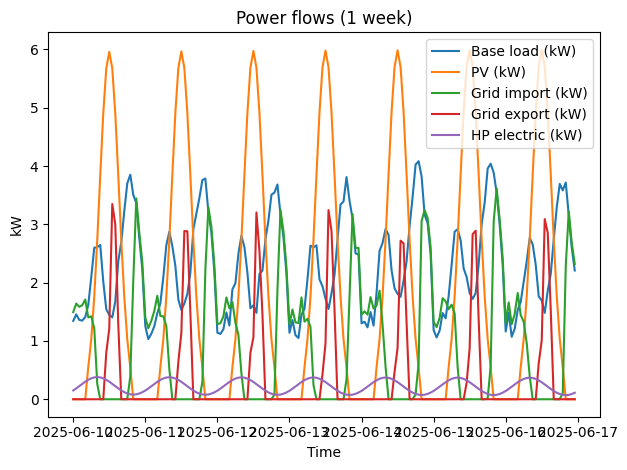

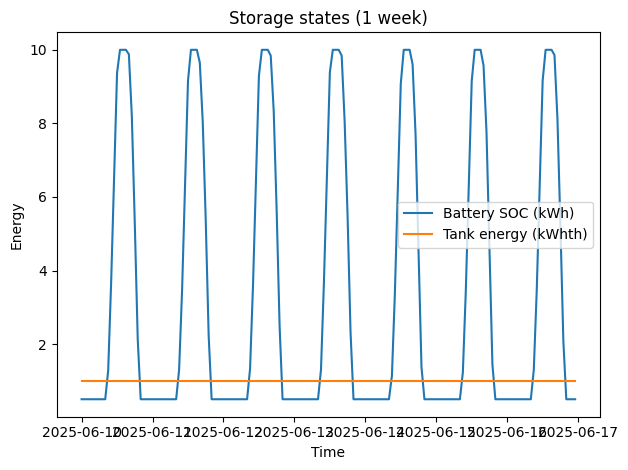

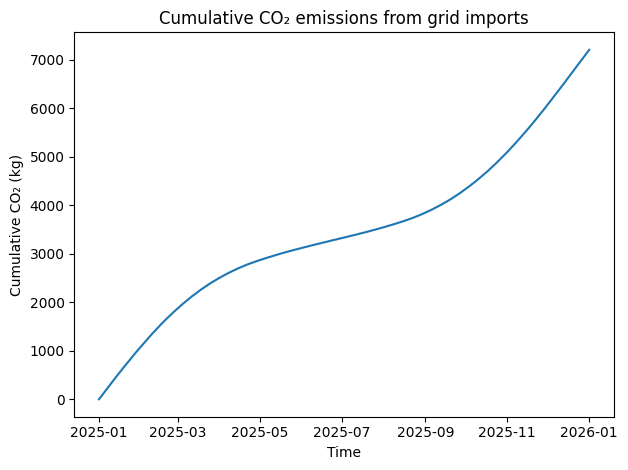


Running OPTIMIZATION (LP) simulation (rolling daily)...

===== Optimization KPIs =====
Total Import (kWh)                      : 22,997.98
Total Export (kWh)                      : 452.43
Total Cost (€)                          : 6,815.14
Peak Import (kW)                        : 8.03
Total CO2 (kg)                          : 7,280.97
Avg Grid CO2 Intensity (kg/kWh)         : 0.311
System CO2 Intensity (kg/kWh consumed)  : 0.232


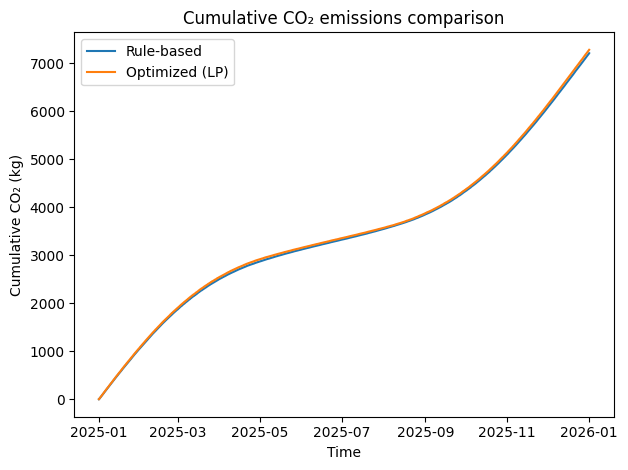

In [11]:
# =========================================================
# MAIN
# =========================================================

def print_kpis(title: str, kpis: Dict[str, float]) -> None:
    """Pretty KPI printing."""
    print(f"\n===== {title} =====")
    for k, v in kpis.items():
        if "€" in k:
            print(f"{k:40s}: {v:,.2f}")
        elif "(kg/kWh" in k:
            print(f"{k:40s}: {v:,.3f}")
        else:
            print(f"{k:40s}: {v:,.2f}")


def main() -> None:
    # --- Build synthetic dataset ---
    sys_cfg = SystemConfig(pv_size_kW=6.0, year=2025, tz="Europe/Berlin", freq="H")
    df = build_profiles(sys_cfg)

    # --- Component configs ---
    battery_rb = BatteryConfig()
    hp_rb = HeatPumpConfig()
    tank_rb = TankConfig()

    # --- Rule-based simulation ---
    print("Running RULE-BASED simulation...")
    out_rb = simulate_rule_based(df, battery_rb, hp_rb, tank_rb)
    kpis_rb = compute_kpis(out_rb)
    print_kpis("Rule-based KPIs", kpis_rb)

    # Plots for rule-based
    plot_week(out_rb, start=f"{sys_cfg.year}-06-10")
    plot_cumulative_co2(out_rb)

    # --- Optimization simulation (optional) ---
    if SCIPY_AVAILABLE:
        print("\nRunning OPTIMIZATION (LP) simulation (rolling daily)...")
        # Separate configs so we don't reuse mutated initial states
        battery_opt = BatteryConfig()
        hp_opt = HeatPumpConfig()
        tank_opt = TankConfig()

        out_opt = optimize_year_lp(df, battery_opt, hp_opt, tank_opt, co2_weight_eur_per_kg=0.0)
        kpis_opt = compute_kpis(out_opt)
        print_kpis("Optimization KPIs", kpis_opt)

        # Compare cumulative CO2 (overlay)
        plt.figure()
        plt.plot(out_rb.index, out_rb["co2_kg"].cumsum(), label="Rule-based")
        plt.plot(out_opt.index, out_opt["co2_kg"].cumsum(), label="Optimized (LP)")
        plt.title("Cumulative CO₂ emissions comparison")
        plt.xlabel("Time")
        plt.ylabel("Cumulative CO₂ (kg)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        print("\nSciPy not found -> Optimization mode skipped.")
        print("Install with: pip install scipy")

if __name__ == "__main__":
    main()
